In [ ]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
RNG = 42
random.seed(RNG)
np.random.seed(RNG)


In [ ]:
base = Path("splitted_dataset")  
splits = ["train", "val", "test"]
classes = ["Benign", "Malignant"]

def build_metadata(base, splits, classes, sample_limit=None):
    rows = []
    for split in splits:
        for cls in classes:
            folder = base / split / cls
            if not folder.exists(): 
                continue
            imgs = list(folder.iterdir())
            if sample_limit:
                imgs = imgs[:sample_limit]
            for p in imgs:
                try:
                    with Image.open(p) as img:
                        w, h = img.size
                        mode = img.mode
                except Exception:
                    w, h, mode = (np.nan, np.nan, "error")
                rows.append({
                    "split": split,
                    "class": cls,
                    "path": str(p),
                    "width": w,
                    "height": h,
                    "mode": mode,
                    "filename": p.name
                })
    return pd.DataFrame(rows)

meta = build_metadata(base, splits, classes)
meta.head()


,split,class,path,width,height,mode,filename
0,train,Benign,splitted_dataset\train\Benign\mdb001 (10).png,227,227,L,mdb001 (10).png
1,train,Benign,splitted_dataset\train\Benign\mdb001 (11).png,227,227,L,mdb001 (11).png
2,train,Benign,splitted_dataset\train\Benign\mdb001 (12).png,227,227,L,mdb001 (12).png
3,train,Benign,splitted_dataset\train\Benign\mdb001 (13).png,227,227,L,mdb001 (13).png
4,train,Benign,splitted_dataset\train\Benign\mdb001 (15).png,227,227,L,mdb001 (15).png


   split      class  count
0   test     Benign    475
1   test  Malignant    475
2  train     Benign   1663
3  train  Malignant   1663
4    val     Benign    238
5    val  Malignant    238


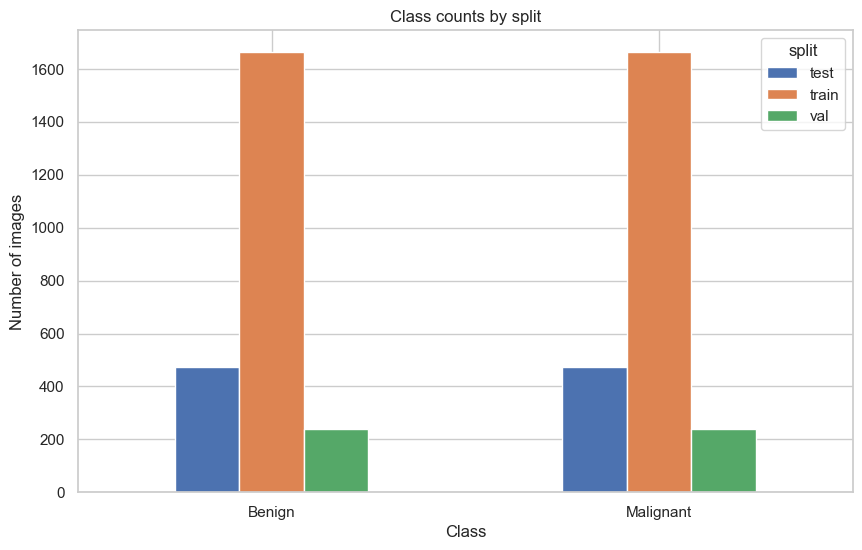


Proportions in train:
        class  prop
2     Benign   0.5
3  Malignant   0.5

Proportions in val:
        class  prop
4     Benign   0.5
5  Malignant   0.5

Proportions in test:
        class  prop
0     Benign   0.5
1  Malignant   0.5


In [ ]:
counts = meta.groupby(["split","class"]).size().reset_index(name="count")
print(counts)

# pivot for plotting
pivot = counts.pivot(index='class', columns='split', values='count').fillna(0).astype(int)
pivot.plot(kind='bar', stacked=False)
plt.title("Class counts by split")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.show()

for s in splits:
    df = counts[counts['split']==s].copy()
    df['prop'] = df['count'] / df['count'].sum()
    print(f"\nProportions in {s}:\n", df[['class','prop']])


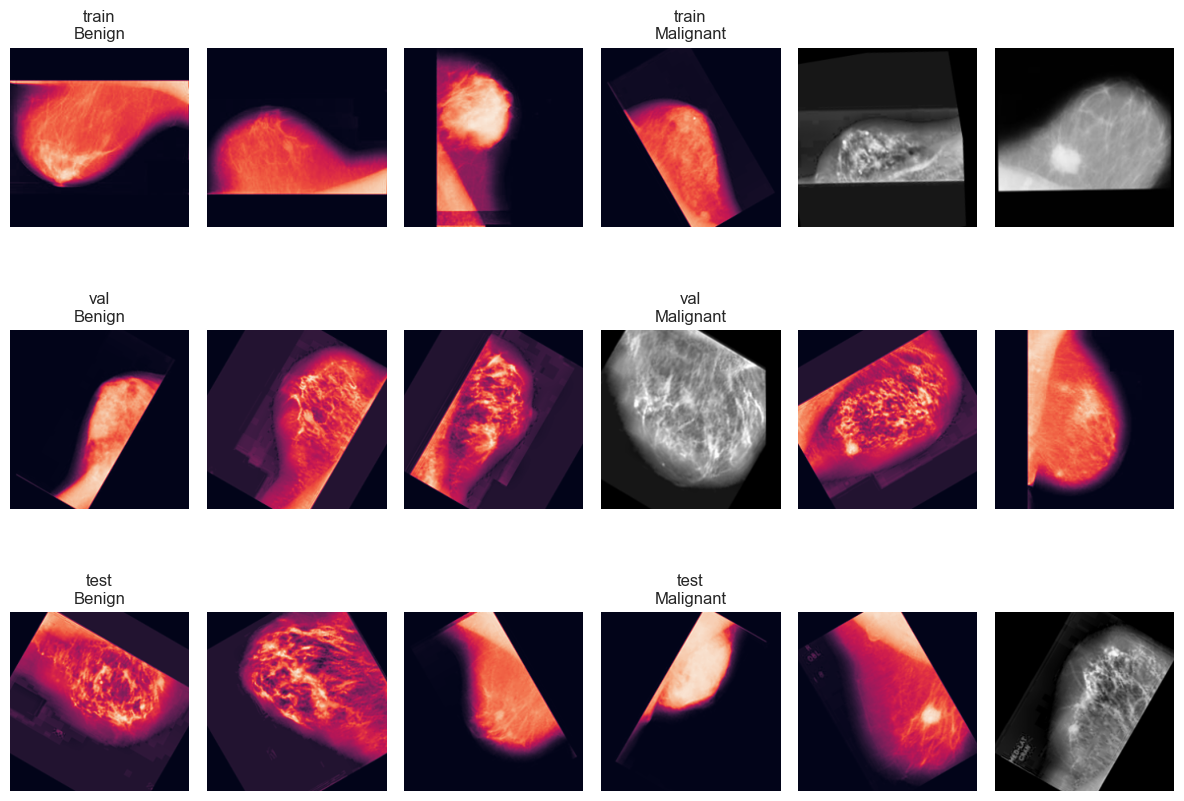

In [9]:
def plot_samples_per_split(base, splits, classes, per_class=4, size=(224,224)):
    cols = len(splits) * len(classes)
    rows = per_class
    plt.figure(figsize=(4*len(splits), 3*per_class))
    idx = 1
    for split in splits:
        for cls in classes:
            folder = base / split / cls
            imgs = list(folder.iterdir())
            if len(imgs) == 0:
                continue
            sample = random.sample(imgs, min(per_class, len(imgs)))
            for i, p in enumerate(sample):
                with Image.open(p) as im:
                    im_disp = im.resize(size)
                plt.subplot(rows, len(splits)*len(classes), idx)
                plt.imshow(im_disp)
                plt.axis("off")
                if i == 0:
                    plt.title(f"{split}\n{cls}")
                idx += 1
    plt.tight_layout()
    plt.show()

plot_samples_per_split(base, splits, classes, per_class=3)


C:\Users\prath\AppData\Local\Temp\ipykernel_17980\1196102059.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = meta.groupby(['split','class']).apply(lambda df: df.sample(min(len(df), 200), random_state=RNG)).reset_index(drop=True)


Feature shape: (1200, 1280)


c:\Users\prath\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


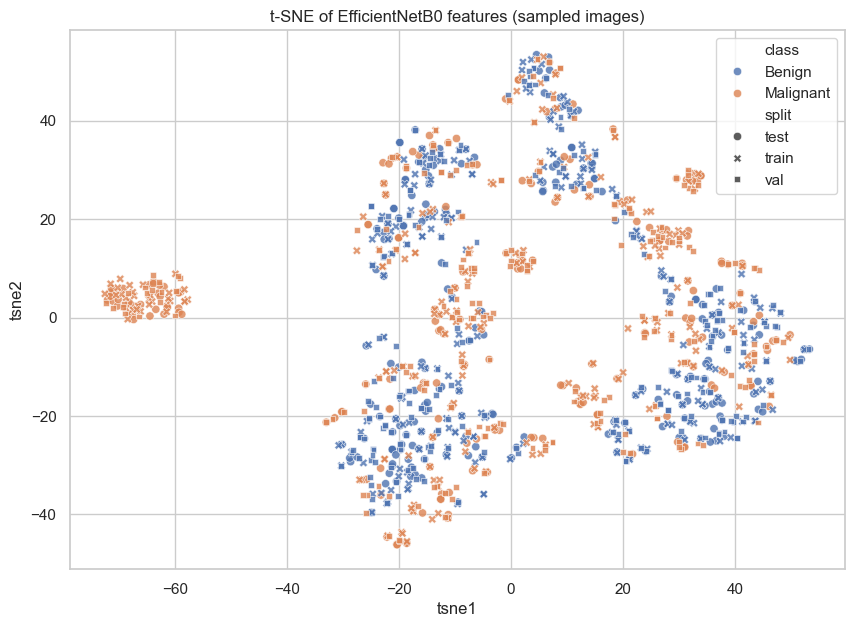

In [12]:
# Build feature extractor
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Prepare a sampled dataset (limit to speed)
sample_df = meta.groupby(['split','class']).apply(lambda df: df.sample(min(len(df), 200), random_state=RNG)).reset_index(drop=True)
paths = sample_df['path'].tolist()

# load and preprocess images in batches to avoid OOM
def load_batch(paths, batch_size=32):
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB").resize((224,224))
                arr = np.array(img, dtype=np.float32)
                arr = preprocess_input(arr)  # EfficientNet preprocessing
                batch_imgs.append(arr)
            except:
                batch_imgs.append(np.zeros((224,224,3), dtype=np.float32))
        yield np.stack(batch_imgs)

# extract features
feats = []
for batch in load_batch(paths, batch_size=32):
    feats.append(feature_extractor.predict(batch, verbose=0))
feats = np.vstack(feats)
print("Feature shape:", feats.shape)

# reduce dims with PCA then t-SNE
pca = PCA(n_components=50, random_state=RNG)
feats_pca = pca.fit_transform(feats)
tsne = TSNE(n_components=2, random_state=RNG, perplexity=30, n_iter=1000)
feats_tsne = tsne.fit_transform(feats_pca)

# plot with labels
sample_df['tsne1'] = feats_tsne[:,0]
sample_df['tsne2'] = feats_tsne[:,1]
plt.figure(figsize=(10,7))
sns.scatterplot(data=sample_df, x='tsne1', y='tsne2', hue='class', style='split', alpha=0.8)
plt.title("t-SNE of EfficientNetB0 features (sampled images)")
plt.show()
